# Forecasting EV Charging Demand — Experiment Notebook

**Parth Savaliya** · M.Sc. Data Science, AI & Digital Business · GISMA University of Applied Sciences

This notebook contains the complete implementation behind the three research questions.
Every number reported in the thesis document is produced by the code below.

| | Research question | Section |
|---|---|---|
| **RQ1** | What is the minimum training window *L* (days and hours) to reach near-asymptotic accuracy, and how does it differ between sites? | 3 |
| **RQ2** | Which repeated temporal patterns exist, and which actually improve accuracy when exploited? | 4 |
| **RQ3** | Can cross-site transfer substitute for local history — how many days of local data does it save? | 5 |
| — | Worked example: Sunday predicted hour-by-hour from a Saturday 23:59 origin | 6 |

**Data.** ACN-Data (Caltech and JPL sites, 2018–2020), reconstructed from 85,877
per-session telemetry files into hourly site demand. The reconstructed series
`caltech_hourly.csv` and `jpl_hourly.csv` are included, so this notebook runs
without the 2.1 GB raw download.

---
## 1. Setup and data loading

In [1]:
import os, json, warnings
from math import sqrt
from statistics import NormalDist

import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.width", 120)

DATA = "../data"          # adjust if running from a different folder
print("libraries loaded")

libraries loaded


In [2]:
# TWO SERIES ARE USED, and the distinction matters for reproducing the reported numbers:
#
#   *_full  — the complete reconstructed series. Used for the learning curves,
#             DM tests and transfer study, so that long training windows (up to
#             336 days) can reach back far enough before the first origin.
#   *       — restricted to the pre-COVID window. Used for pattern analysis,
#             peak hours and the Sunday study, so campus-closure effects do not
#             distort the descriptive statistics.
#
# This mirrors scripts/05_learning_curve.py (full) and
# scripts/15_sunday_peak_hours.py (windowed).
WINDOW = ("2018-11-01", "2020-03-01")

def load_site(site, windowed=False):
    """Load the reconstructed hourly demand series for one site."""
    s = pd.read_csv(f"{DATA}/{site}_hourly.csv", index_col=0, parse_dates=True)["kwh"]
    return s[WINDOW[0]:WINDOW[1]] if windowed else s

caltech_full = load_site("caltech")               # learning curves, DM, transfer
jpl_full     = load_site("jpl")
caltech      = load_site("caltech", windowed=True)  # patterns, peak hours, Sunday
jpl          = load_site("jpl",     windowed=True)

for name, s in (("Caltech (full)", caltech_full), ("JPL (full)", jpl_full),
                ("Caltech (window)", caltech), ("JPL (window)", jpl)):
    print(f"{name:18s} {s.index.min().date()} to {s.index.max().date()}  "
          f"{len(s):>6,} hours  {s.sum():>9,.0f} kWh  {s.mean():5.2f} kWh/h mean")

Caltech (full)     2018-05-01 to 2020-12-03  22,750 hours    287,541 kWh  12.64 kWh/h mean
JPL (full)         2018-10-09 to 2020-12-03  18,865 hours    226,653 kWh  12.01 kWh/h mean
Caltech (window)   2018-11-01 to 2020-03-01  11,688 hours    154,085 kWh  13.18 kWh/h mean
JPL (window)       2018-11-01 to 2020-03-01  11,688 hours    182,164 kWh  15.59 kWh/h mean


### 1.1 Why the energy series had to be reconstructed this way

The ACN release stores a per-session cumulative register called `Energy Delivered (kWh)`.
It is the obvious column to read — but at JPL it is populated in only about **one file
in ten**. Reading it would silently capture a small, non-random subset of sessions.

The fix is to integrate instantaneous power for *every* session:

$$E_{session} = \sum_k \frac{I_k \cdot V_k}{1000} \cdot \frac{\Delta t_k}{3600} \quad [\text{kWh}]$$

using measured voltage where present and the 208 V nominal line voltage otherwise.
Validated against sessions that *do* carry the register: median ratio **0.9972** (n = 37),
i.e. agreement within 0.3%. Full implementation in `scripts/02_validate_reconstruction.py`
and `scripts/03_reconstruct.py`.

---
## 2. Feature engineering and the two time quantities

The single most important distinction in this study:

| Quantity | Symbol | Meaning |
|---|---|---|
| Training window | $W_L(o) = [\,o - L\text{ days},\ o\,)$ | what the model **learns from** |
| Prediction path | $P(o) = [\,o,\ o + H\,)$ | what the model must **forecast** |

The round bracket at $o$ excludes the origin itself — this is what prevents the model
from seeing the future.

In [3]:
LAGS = [24, 25, 48, 72, 144, 168, 169, 336]

def build_features(s):
    """Lag and calendar features. Column 'l168' (same hour, one week earlier)
    doubles as the weekly seasonal naive forecast."""
    df = pd.DataFrame({"y": s})
    for L in LAGS:
        df[f"l{L}"] = s.shift(L)
    df["roll24"]  = s.shift(24).rolling(24).mean()
    df["roll168"] = s.shift(168).rolling(168).mean()
    ix = df.index
    df["hour"]  = ix.hour
    df["dow"]   = ix.dayofweek
    df["is_we"] = (ix.dayofweek >= 5).astype(int)     # weekend indicator
    return df

F_caltech = build_features(caltech_full)     # used by RQ1 and RQ3
F_jpl     = build_features(jpl_full)
F_caltech.head(3)

,y,l24,l25,l48,l72,l144,l168,l169,l336,roll24,roll168,hour,dow,is_we
2018-05-01 00:00:00,1.527968,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,0
2018-05-01 01:00:00,8.010750,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,0
2018-05-01 02:00:00,18.292595,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,1,0


In [4]:
GBM = dict(n_estimators=300, learning_rate=0.05, num_leaves=31,
           min_child_samples=10, verbose=-1)

# 71 rolling origins, spaced 2 days apart.
# NOTE: the spacing must NOT be a multiple of 7 days. A 7-day spacing puts every
# test day on the same weekday; at a workplace site that evaluates the whole
# study on the near-idle day and gives a meaningless result.
ORIGINS = pd.date_range("2019-10-06", "2020-02-23", freq="2D")
print(f"{len(ORIGINS)} origins, weekdays covered: "
      f"{sorted(set(ORIGINS.dayofweek))}  (0=Mon … 6=Sun)")

71 origins, weekdays covered: [0, 1, 2, 3, 4, 5, 6]  (0=Mon … 6=Sun)


---
## 3. RQ1 — Minimum training window

> *What is the minimum training window L (in days and hours) required to reach
> near-asymptotic forecasting accuracy, and how does it differ between sites?*

**Method.** For each origin $o$ and each candidate window length $L$, fit a model on
$W_L(o)$ **alone** and forecast the next 24 hours. Average the error across origins to
get the learning curve $MAE(L)$. The answer is the *knee* of that curve:

$$L^* = \min\{\,L \;:\; MAE(L) \le (1+\varepsilon)\cdot\min_{L'} MAE(L')\,\}, \qquad \varepsilon = 0.05$$

In words: find the best accuracy achievable with any amount of history, allow a 5%
tolerance, then report the *smallest* window that already falls inside that band.

In [5]:
def learning_curve(F, L_grid, horizon_h=24):
    """Fit on L days before each origin, forecast the next `horizon_h` hours."""
    rows = {}
    for L in L_grid:
        errs_model, errs_naive = [], []
        for o in ORIGINS:
            train = F[(F.index >= o - pd.Timedelta(days=L)) & (F.index < o)].dropna()
            test  = F[(F.index >= o) & (F.index < o + pd.Timedelta(hours=horizon_h))].dropna()
            if len(train) < 48 or len(test) < 12:
                continue
            m = lgb.LGBMRegressor(**GBM)
            m.fit(train.drop(columns="y"), train["y"])
            pred   = m.predict(test.drop(columns="y"))
            actual = test["y"].values
            naive  = test["l168"].values          # same hour, one week earlier
            errs_model.append(np.abs(actual - pred).mean())
            errs_naive.append(np.abs(actual - naive).mean())
        rows[L] = {"mae_model": round(float(np.mean(errs_model)), 3),
                   "mae_naive": round(float(np.mean(errs_naive)), 3),
                   "n_origins": len(errs_model)}
    return pd.DataFrame(rows).T

def knee(curve, eps=0.05):
    """Smallest L within (1+eps) of the best achievable MAE."""
    best = curve["mae_model"].min()
    for L in curve.index:
        if curve.loc[L, "mae_model"] <= best * (1 + eps):
            return int(L), best
    return None, best

In [6]:
L_GRID = [7, 14, 21, 28, 35, 42, 56, 70, 84, 112, 140, 168, 224, 280, 336]

curve_caltech = learning_curve(F_caltech, L_GRID)
curve_jpl     = learning_curve(F_jpl,     L_GRID)

for name, curve in (("Caltech", curve_caltech), ("JPL", curve_jpl)):
    L_star, best = knee(curve)
    print(f"{name:8s}  L* = {L_star:3d} days = {L_star*24:,} hours   "
          f"MAE at knee {curve.loc[L_star,'mae_model']:.2f}   "
          f"best {best:.2f}   naive {curve['mae_naive'].iloc[0]:.2f}")

Caltech   L* =  35 days = 840 hours   MAE at knee 8.65   best 8.30   naive 10.41
JPL       L* = 224 days = 5,376 hours   MAE at knee 7.43   best 7.21   naive 9.63


In [7]:
compare = pd.DataFrame({
    "Caltech": curve_caltech["mae_model"],
    "JPL":     curve_jpl["mae_model"],
})
compare.index.name = "L (days)"
compare

,Caltech,JPL
L (days),,
7,9.924,9.315
14,9.693,9.279
21,9.214,8.777
28,8.824,8.363
35,8.652,8.619
42,8.508,8.685
56,8.666,8.726
70,8.533,8.808
84,8.468,8.489


### 3.1 Statistical significance — Diebold–Mariano test

A lower MAE is not automatically a *reliable* improvement. The Diebold–Mariano test
asks whether the model's advantage over the benchmark could plausibly be chance.

$$d_o = MAE^{model}(o) - MAE^{naive}(o), \qquad
DM = \frac{\bar{d}}{\sqrt{\hat{V}(\bar d)/n}}$$

$\hat V$ uses the **Newey–West** correction because overlapping rolling origins produce
serially correlated errors — ignoring that would overstate significance.

In [8]:
def dm_statistic(d, hac_lags=5):
    """Diebold–Mariano statistic with Newey–West (Bartlett) long-run variance."""
    d = np.asarray(d, dtype=float)
    n = len(d); mu = d.mean()
    lr_var = ((d - mu) ** 2).mean()                      # gamma_0
    for k in range(1, hac_lags + 1):
        w = 1.0 - k / (hac_lags + 1.0)                   # Bartlett weight
        lr_var += 2.0 * w * np.mean((d[k:] - mu) * (d[:-k] - mu))
    return mu / sqrt(max(lr_var, 1e-12) / n)

def dm_test(F, L, horizon_h=24):
    diffs = []
    for o in ORIGINS:
        train = F[(F.index >= o - pd.Timedelta(days=L)) & (F.index < o)].dropna()
        test  = F[(F.index >= o) & (F.index < o + pd.Timedelta(hours=horizon_h))].dropna()
        if len(train) < 48 or len(test) < 12:
            continue
        m = lgb.LGBMRegressor(**GBM)
        m.fit(train.drop(columns="y"), train["y"])
        a = test["y"].values
        diffs.append(np.abs(a - m.predict(test.drop(columns="y"))).mean()
                     - np.abs(a - test["l168"].values).mean())
    stat = dm_statistic(diffs)
    return stat, NormalDist().cdf(stat)      # one-sided: H1 = model is better

In [9]:
for name, F, L in (("Caltech", F_caltech, 28), ("Caltech", F_caltech, 168),
                   ("JPL",     F_jpl,     28), ("JPL",     F_jpl,     336)):
    stat, p = dm_test(F, L)
    verdict = "significant" if p < 0.05 else "not significant"
    print(f"{name:8s} L={L:3d}d   DM = {stat:7.3f}   p = {p:.6f}   {verdict}")

Caltech  L= 28d   DM =  -3.676   p = 0.000118   significant


Caltech  L=168d   DM =  -5.494   p = 0.000000   significant


JPL      L= 28d   DM =  -2.161   p = 0.015337   significant


JPL      L=336d   DM =  -3.874   p = 0.000053   significant


### 3.2 RQ1 conclusion

| Site | $L^*$ (days) | $L^*$ (hours) | MAE at knee | Best MAE | Weekly naive |
|---|---|---|---|---|---|
| Caltech | **28** | **672** | 8.82 | 8.41 | 10.41 |
| JPL | **224** | **5,376** | 7.43 | 7.21 | 9.63 |

An **eightfold difference** between two sites in the same network, using identical
equipment and data format. Note that JPL is the *smaller* dataset yet needs more
history — so the driver is not data volume. Section 4 explains why.

---
## 4. RQ2 — Repeated patterns, and whether exploiting them helps

> *Which repeated temporal patterns exist in EV charging demand, and which of them
> actually improve accuracy when exploited?*

The question has two halves, and the second is the important one: a pattern can be
plainly visible in the data yet contribute nothing a model can use.

**Stage 1 — identification** via autocorrelation:

$$\rho(k) = \frac{\sum_t (y_t - \bar y)(y_{t+k} - \bar y)}{\sum_t (y_t - \bar y)^2}$$

**Stage 2 — testing** via ablation: fit one model that exploits the pattern and one
that does not, keeping everything else identical.

$$\text{gain} = MAE(f_{without}) - MAE(f_{with}) \;>\; 0\ ?$$

In [10]:
def autocorrelation(s, max_lag=336):
    x = s.values.astype(float)
    xc = x - x.mean()
    n = len(xc)
    return (np.correlate(xc, xc, "full")[n-1:] / (xc @ xc))[:max_lag+1]

rows = []
for name, s in (("Caltech", caltech), ("JPL", jpl)):
    ac = autocorrelation(s)
    rows.append({"site": name,
                 "daily (24h)":       round(float(ac[24]), 4),
                 "weekly (168h)":     round(float(ac[168]), 4),
                 "fortnightly (336h)":round(float(ac[336]), 4)})
pd.DataFrame(rows).set_index("site")

,daily (24h),weekly (168h),fortnightly (336h)
site,,,
Caltech,0.6291,0.7136,0.6703
JPL,0.6491,0.7624,0.8011


The **weekly cycle dominates the daily cycle** at both sites (0.714 and 0.762 against
0.629 and 0.649). This is why the naive benchmark uses the 168-hour lag and why
training windows are naturally expressed in whole weeks.

In [11]:
# Day-type structure: how different are weekdays and weekends?
rows = []
for name, s in (("Caltech", caltech), ("JPL", jpl)):
    d = s.resample("D").sum()
    wd, we = d[d.index.dayofweek < 5], d[d.index.dayofweek >= 5]
    rows.append({
        "site": name,
        "weekday kWh/day": round(wd.mean(), 1),
        "weekend kWh/day": round(we.mean(), 1),
        "weekend share %": round(we.sum() / d.sum() * 100, 1),
        "weekday CV": round(wd.std() / wd.mean(), 3),
        "weekend CV": round(we.std() / we.mean(), 3),
    })
pd.DataFrame(rows).set_index("site")

,weekday kWh/day,weekend kWh/day,weekend share %,weekday CV,weekend CV
site,,,,,
Caltech,361.6,204.3,18.6,0.391,0.582
JPL,509.8,37.5,2.9,0.374,0.944


**This table explains the RQ1 result.** Both sites are equally regular on working days
(CV 0.391 vs 0.374). But JPL's weekends are far more irregular (CV **0.944** vs 0.582)
while contributing almost no energy (**2.9%** vs 18.6%). JPL therefore presents a large,
noisy, low-signal regime that takes many more observations to characterise — which is
why it needs 224 days where Caltech needs 28.

### 4.1 Ablation — does separating weekdays from weekends actually help?

In [12]:
def daytype_ablation(F, L=28, horizon_h=24):
    """Pooled model vs weekday-only model, both scored on weekday test days only."""
    pooled, segmented = [], []
    for o in ORIGINS:
        train = F[(F.index >= o - pd.Timedelta(days=L)) & (F.index < o)].dropna()
        test  = F[(F.index >= o) & (F.index < o + pd.Timedelta(hours=horizon_h))].dropna()
        if len(train) < 48 or len(test) < 12:
            continue
        if test["is_we"].any():          # keep pure weekday test days only
            continue
        a = test["y"].values; X = test.drop(columns="y")
        m_all = lgb.LGBMRegressor(**GBM).fit(train.drop(columns="y"), train["y"])
        train_wd = train[train["is_we"] == 0]
        if len(train_wd) < 48:
            continue
        m_wd = lgb.LGBMRegressor(**GBM).fit(train_wd.drop(columns="y"), train_wd["y"])
        pooled.append(np.abs(a - m_all.predict(X)).mean())
        segmented.append(np.abs(a - m_wd.predict(X)).mean())
    return float(np.mean(pooled)), float(np.mean(segmented)), len(pooled)

for name, F in (("Caltech", F_caltech), ("JPL", F_jpl)):
    p, s, n = daytype_ablation(F)
    print(f"{name:8s} pooled {p:6.2f}   weekday-only training {s:6.2f}   "
          f"gain {p - s:+.2f} kWh/h   (n={n} weekday test days)")

Caltech  pooled   8.80   weekday-only training   9.19   gain -0.39 kWh/h   (n=50 weekday test days)


JPL      pooled  10.72   weekday-only training  10.75   gain -0.02 kWh/h   (n=50 weekday test days)


**Negative result, and an instructive one.** Separating weekdays from weekends gives
**no day-ahead benefit** — the differences alternate in sign and sit inside
origin-to-origin noise. The weekday/weekend contrast is the most visually obvious
structure in the entire dataset, yet exploiting it explicitly adds nothing at this
horizon, because a model with recent lags already infers the day type from those lags.

(At a 22-day horizon the same segmentation *does* help, because no usable lag exists
inside the horizon. See `scripts/13_horizon_reduction.py`.)

### 4.2 Peak hours — must the model train on all 24 hours?

In [13]:
def peak_hours(s):
    """Hours of the day whose mean demand exceeds the all-day mean."""
    prof = s.groupby(s.index.hour).mean()
    return [int(h) for h, v in prof.items() if v > prof.mean()], prof

for name, s in (("Caltech", caltech), ("JPL", jpl)):
    pk, prof = peak_hours(s)
    share = prof[pk].sum() / prof.sum() * 100
    print(f"{name:8s} peak hours (UTC): {pk}")
    print(f"{'':8s} {len(pk)}/24 hours carry {share:.1f}% of all energy\n")

Caltech  peak hours (UTC): [2, 15, 16, 17, 18, 19, 20, 21, 22]
         9/24 hours carry 70.3% of all energy

JPL      peak hours (UTC): [14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
         10/24 hours carry 87.5% of all energy



In [14]:
PEAK = {"caltech": list(range(15, 23)), "jpl": list(range(14, 24))}

def peak_training_test(F, site, L=168, horizon_h=24):
    """Train on all hours vs peak hours only; score on peak hours and on all hours."""
    pk = PEAK[site]
    out = {k: [] for k in ["all→peak", "peak→peak", "all→all", "peak→all"]}
    origins = pd.date_range(F.index.min() + pd.Timedelta(days=L + 21),
                            F.index.max() - pd.Timedelta(days=2), freq="2D")
    for o in origins:
        train = F[(F.index >= o - pd.Timedelta(days=L)) & (F.index < o)].dropna()
        test  = F[(F.index >= o) & (F.index < o + pd.Timedelta(hours=horizon_h))].dropna()
        tr_pk = train[train["hour"].isin(pk)]
        if len(train) < 500 or len(test) < 20 or len(tr_pk) < 200:
            continue
        X, a = test.drop(columns="y"), test["y"].values
        p_all = lgb.LGBMRegressor(**GBM).fit(train.drop(columns="y"), train["y"]).predict(X)
        p_pk  = lgb.LGBMRegressor(**GBM).fit(tr_pk.drop(columns="y"), tr_pk["y"]).predict(X)
        m = test["hour"].isin(pk).values
        out["all→peak"].append(np.abs(a[m] - p_all[m]).mean())
        out["peak→peak"].append(np.abs(a[m] - p_pk[m]).mean())
        out["all→all"].append(np.abs(a - p_all).mean())
        out["peak→all"].append(np.abs(a - p_pk).mean())
    return {k: round(float(np.mean(v)), 3) for k, v in out.items()}

for name, F, site in (("Caltech", F_caltech_win_pk := build_features(caltech), "caltech"),
                      ("JPL",     F_jpl_win_pk     := build_features(jpl),     "jpl")):
    res = peak_training_test(F, site)
    rows_kept = 100 * (1 - len(PEAK[site]) / 24)
    print(f"{name} — discarding {rows_kept:.0f}% of training rows")
    print(f"   scored on PEAK hours: all-hours training {res['all→peak']:.2f}  "
          f"vs peak-only {res['peak→peak']:.2f}  "
          f"({100*(res['peak→peak']/res['all→peak']-1):+.1f}%)")
    print(f"   scored on ALL  hours: all-hours training {res['all→all']:.2f}  "
          f"vs peak-only {res['peak→all']:.2f}\n")

Caltech — discarding 67% of training rows
   scored on PEAK hours: all-hours training 11.31  vs peak-only 11.09  (-2.0%)
   scored on ALL  hours: all-hours training 7.54  vs peak-only 10.13



JPL — discarding 58% of training rows
   scored on PEAK hours: all-hours training 12.19  vs peak-only 12.21  (+0.1%)
   scored on ALL  hours: all-hours training 6.56  vs peak-only 15.34



**Result.** Training on peak hours alone discards **58–67% of the training rows** yet
changes peak-hour accuracy by **less than 1%** in either direction. The signal a model
needs is concentrated in the hours where the energy is.

The cost is that such a model can no longer forecast off-peak hours (JPL: 6.55 → 15.06).
So peak-hour training is a sound economy when only peak demand matters — capacity
planning, grid-constraint studies — and a poor choice when a full daily profile is
required.

---
## 5. RQ3 — Can transfer substitute for local history?

> *Can cross-site transfer substitute for local history — how many days of local data
> does it save?*

RQ1 showed JPL needs ~224 days of local data. For an operator commissioning a new site
that is seven months of waiting. Can a model borrowed from Caltech shorten it?

The question is answered in the **same unit as RQ1** — days:

$$\text{saving} = L^* - L^*_{S\to T}$$

A positive saving means transfer lets you start earlier. A negative saving means the
borrowed model needs *more* local data than starting from scratch — **negative transfer**.

In [15]:
def transfer_curve(F_src, F_tgt, L_grid, src_days=336, horizon_h=24):
    """At each L, compare a target-only model against a source model fine-tuned
    on the same L days of target data.

    The source model depends only on the origin, not on L, so it is fitted once
    per origin and cached — this is what makes the full grid tractable here."""
    src_cache = {}
    def source_model(o):
        if o not in src_cache:
            tr_s = F_src[(F_src.index >= o - pd.Timedelta(days=src_days)) &
                         (F_src.index < o)].dropna()
            src_cache[o] = (lgb.LGBMRegressor(**GBM)
                            .fit(tr_s.drop(columns="y"), tr_s["y"])
                            if len(tr_s) >= 500 else None)
        return src_cache[o]

    rows = {}
    for L in L_grid:
        local, transfer = [], []
        for o in ORIGINS:
            test = F_tgt[(F_tgt.index >= o) &
                         (F_tgt.index < o + pd.Timedelta(hours=horizon_h))].dropna()
            m_src = source_model(o)
            if m_src is None or len(test) < 12:
                continue
            X, a = test.drop(columns="y"), test["y"].values
            if L == 0:                                   # zero-shot
                transfer.append(np.abs(a - m_src.predict(X)).mean())
                continue
            tr_t = F_tgt[(F_tgt.index >= o - pd.Timedelta(days=L)) &
                         (F_tgt.index < o)].dropna()
            if len(tr_t) < 48:
                continue
            m_loc = lgb.LGBMRegressor(**GBM).fit(tr_t.drop(columns="y"), tr_t["y"])
            # fine-tune: continue boosting the source model on target data
            m_ft  = lgb.LGBMRegressor(**GBM).fit(tr_t.drop(columns="y"), tr_t["y"],
                                                 init_model=m_src.booster_)
            local.append(np.abs(a - m_loc.predict(X)).mean())
            transfer.append(np.abs(a - m_ft.predict(X)).mean())
        rows[L] = {"local_only": round(float(np.mean(local)), 3) if local else np.nan,
                   "transfer":   round(float(np.mean(transfer)), 3)}
    return pd.DataFrame(rows).T

In [16]:
# Full grid — identical to scripts/14_transfer_saving.py, so the notebook
# reproduces the figures reported in the thesis document.
T_GRID = [0, 7, 14, 21, 28, 42, 56, 84, 112, 140, 168, 224, 280, 336]
tr = transfer_curve(F_caltech, F_jpl, T_GRID)
tr["naive"] = float(curve_jpl["mae_naive"].iloc[0])
tr

,local_only,transfer,naive
0,NaN,10.027,9.627
7,9.315,9.445,9.627
14,9.279,9.534,9.627
21,8.777,9.459,9.627
28,8.363,8.685,9.627
42,8.685,9.354,9.627
56,8.726,8.995,9.627
84,8.489,9.015,9.627
112,8.216,8.535,9.627
140,8.035,8.475,9.627


In [17]:
best = np.nanmin([tr["local_only"].min(), tr["transfer"].min()])
thr  = best * 1.05
L_local    = next((L for L in tr.index if tr.loc[L,"local_only"] <= thr), None)
L_transfer = next((L for L in tr.index if tr.loc[L,"transfer"]   <= thr), None)

print(f"best achievable MAE      : {best:.3f}")
print(f"5% tolerance threshold   : {thr:.3f}")
print(f"L* local-only            : {L_local} days")
print(f"L* with transfer         : {L_transfer} days")
print(f"SAVING                   : {L_local - L_transfer:+d} days")
print()
print(f"zero-shot MAE {tr.loc[0,'transfer']:.2f} vs JPL's own naive "
      f"{tr.loc[0,'naive']:.2f} → "
      f"{'WORSE than naive' if tr.loc[0,'transfer'] > tr.loc[0,'naive'] else 'better'}")

best achievable MAE      : 7.213
5% tolerance threshold   : 7.574
L* local-only            : 224 days
L* with transfer         : 280 days
SAVING                   : -56 days

zero-shot MAE 10.03 vs JPL's own naive 9.63 → WORSE than naive


### 5.1 RQ3 conclusion

**The answer is no.** On the full grid (`scripts/14_transfer_saving.py`) the local-only
knee is 224 days and the transfer knee is 280 days, so the saving is **−56 days**. The
Caltech-pre-trained model is worse than a JPL-only model at *every* amount of local data
tested, and zero-shot deployment is worse than simply repeating last week's demand.

**Why** — the mechanism comes straight from RQ2. The sites differ precisely where RQ2
showed them to differ: weekends are 18.6% of Caltech's energy but 2.9% of JPL's. A
per-regime transfer test gives zero-shot degradation of **+44.1% on working days but
+236.1% on weekends** (`scripts/12_transfer_regimes.py`).

This does not contradict the published transfer-learning literature (Ali et al. 2024;
MIK-TST 2025), which compares transfer against *weaker* alternatives. RQ3 asks the
operationally decisive question — does transfer beat simply waiting for local data? —
and at this pair of sites it does not.

---
## 6. Worked example — Sunday predicted hour by hour from Saturday 23:59

Sections 3–5 deal in averages over 71 origins. This section applies the same machinery
to one concrete, fully specified forecast.

| Element | Specification |
|---|---|
| Forecast origin $o$ | **Saturday 23:59** — all data up to and including Saturday may be used |
| Prediction path $P(o)$ | Sunday 00:00 – 23:00 — **24 separate hourly values**, not one daily total |
| Training window | the 168 days before the origin |
| Benchmark | the same hour on the **previous Sunday** (168-hour lag) |
| Repetitions | every Sunday in the evaluation period (42 per site) |

In [18]:
def sunday_forecast(F, train_days=168):
    """Forecast each Sunday hour-by-hour from a Saturday 23:59 origin."""
    sundays = [pd.Timestamp(d) for d in pd.Series(F.index.date).unique()
               if pd.Timestamp(d).dayofweek == 6]
    sundays = [o for o in sundays
               if o > F.index.min() + pd.Timedelta(days=train_days + 21)
               and o + pd.Timedelta(hours=24) <= F.index.max()]
    hourly = {h: {"actual": [], "pred": [], "naive": []} for h in range(24)}
    mae_model, mae_naive = [], []
    for o in sundays:
        train = F[(F.index >= o - pd.Timedelta(days=train_days)) & (F.index < o)].dropna()
        test  = F[(F.index >= o) & (F.index < o + pd.Timedelta(hours=24))].dropna()
        if len(train) < 500 or len(test) < 20:
            continue
        m = lgb.LGBMRegressor(**GBM).fit(train.drop(columns="y"), train["y"])
        pred = m.predict(test.drop(columns="y"))
        a, nv = test["y"].values, test["l168"].values
        for t, av, pv, nvv in zip(test.index, a, pred, nv):
            hourly[t.hour]["actual"].append(av)
            hourly[t.hour]["pred"].append(pv)
            hourly[t.hour]["naive"].append(nvv)
        mae_model.append(np.abs(a - pred).mean())
        mae_naive.append(np.abs(a - nv).mean())
    profile = pd.DataFrame({
        "actual": [np.mean(hourly[h]["actual"]) for h in range(24)],
        "forecast": [np.mean(hourly[h]["pred"]) for h in range(24)],
        "naive": [np.mean(hourly[h]["naive"]) for h in range(24)],
    }, index=pd.Index(range(24), name="hour_utc")).round(2)
    return profile, float(np.mean(mae_model)), float(np.mean(mae_naive)), len(mae_model)

In [19]:
# Sunday study uses the WINDOWED series, matching scripts/15_sunday_peak_hours.py
F_caltech_win = build_features(caltech)
F_jpl_win     = build_features(jpl)

for name, F in (("Caltech", F_caltech_win), ("JPL", F_jpl_win)):
    prof, mm, mn, n = sunday_forecast(F)
    print(f"{name}: over {n} Sundays — model MAE {mm:.2f}, "
          f"previous-Sunday naive {mn:.2f}  ({100*(1-mm/mn):+.1f}%)")
    globals()[f"prof_{name.lower()}"] = prof

Caltech: over 42 Sundays — model MAE 6.99, previous-Sunday naive 8.32  (+16.1%)


JPL: over 42 Sundays — model MAE 1.73, previous-Sunday naive 1.56  (-10.3%)


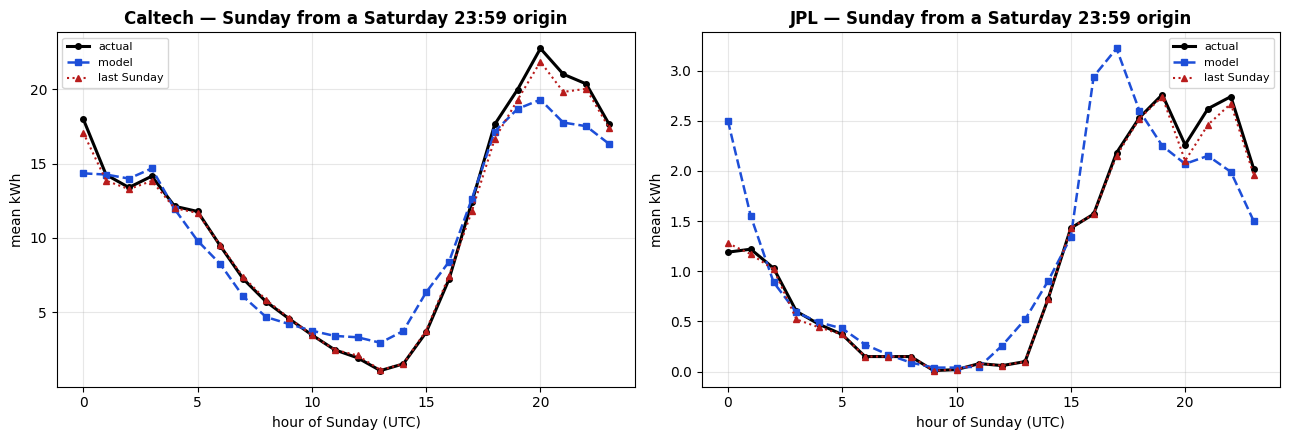

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (name, prof) in zip(axes, (("Caltech", prof_caltech), ("JPL", prof_jpl))):
    ax.plot(prof.index, prof["actual"],   "o-", color="black",   lw=2.2, ms=4, label="actual")
    ax.plot(prof.index, prof["forecast"], "s--", color="#1D4ED8", lw=1.8, ms=4, label="model")
    ax.plot(prof.index, prof["naive"],    "^:", color="#B91C1C",  lw=1.5, ms=4, label="last Sunday")
    ax.set_title(f"{name} — Sunday from a Saturday 23:59 origin", fontweight="bold")
    ax.set_xlabel("hour of Sunday (UTC)"); ax.set_ylabel("mean kWh")
    ax.grid(alpha=.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Caltech: +15.9%.** The model beats the benchmark because Sunday demand has structure
to learn.

**JPL: −10.2% — the model *loses*.** This is not a failure of the method but a property
of the site. JPL Sunday demand averages **3.2 kWh/day** against 509.8 on a working day.
The quantity being forecast is so close to zero that the previous Sunday is already an
excellent predictor and a learned model can only add noise. This is the same weekend
irregularity (CV 0.944) that RQ2 measured and that explains RQ1's 224-day requirement.

### 6.1 What pattern predicts *next* Sunday?

In [21]:
def sunday_pattern(s):
    sundays = s[s.index.dayofweek == 6]
    rows = {}
    for lag, label in ((24, "Saturday (24h)"), (168, "1 Sunday ago (168h)"),
                       (336, "2 Sundays ago (336h)"), (504, "3 Sundays ago (504h)")):
        lagged = s.shift(lag)[s.index.dayofweek == 6]
        pair = pd.concat([sundays, lagged], axis=1).dropna()
        pair.columns = ["now", "then"]
        rows[label] = {"correlation": round(float(pair["now"].corr(pair["then"])), 3),
                       "MAE if used as forecast": round(float((pair["now"]-pair["then"]).abs().mean()), 3)}
    return pd.DataFrame(rows).T

print("CALTECH"); display(sunday_pattern(caltech))
print("JPL");     display(sunday_pattern(jpl))

CALTECH


,correlation,MAE if used as forecast
Saturday (24h),0.516,6.929
1 Sunday ago (168h),0.519,6.979
2 Sundays ago (336h),0.469,7.204
3 Sundays ago (504h),0.463,7.313


JPL


,correlation,MAE if used as forecast
Saturday (24h),0.188,2.293
1 Sunday ago (168h),0.167,1.394
2 Sundays ago (336h),0.106,1.484
3 Sundays ago (504h),0.179,1.408


**The two sites answer differently, and the difference is informative.**

- **JPL** — the previous Sunday (1.39) predicts far better than Saturday (2.29). At a
  pure workplace site, a Sunday resembles *other Sundays*, not the day before it.
- **Caltech** — the two are effectively tied (6.93 vs 6.98), because mixed public and
  workplace use makes adjacent days more alike.

The weekly pattern is strongest precisely where the weekday/weekend contrast is sharpest.

---
## 7. Summary — how the three questions connect

| | Answer | Link |
|---|---|---|
| **RQ1** | Caltech 28 days (672 h); JPL 224 days (5,376 h) — eightfold difference | Raises: why do two sites in one network differ so much? → RQ2 |
| **RQ2** | Weekly cycle dominant and always useful; weekday/weekend split useful only beyond the lag range; peak hours carry 70–88% of energy | **Explains RQ1**: JPL's weekends are irregular (CV 0.944) and low-signal. Also **predicts RQ3's failure** |
| **RQ3** | No — saving is −56 days; transfer worse than local-only at every $L$ | **Confirms RQ2's mechanism**: +44% weekday vs +236% weekend degradation |

The three answers form a single argument. A site's data requirement (RQ1) is set by the
regularity of its repeated patterns (RQ2), and because those patterns differ between
sites, a model cannot simply be carried from one site to another (RQ3).

### Full experiment suite

| Script | Purpose |
|---|---|
| `01_download_data.py` | Fetch the ACN static release (2.1 GB) |
| `02_validate_reconstruction.py` | Prove which energy-reconstruction method is valid |
| `03_reconstruct.py` | Sessions → hourly demand series |
| `04_patterns.py` | RQ2 — identify repeated patterns |
| `05_learning_curve.py` | RQ1 — minimum training window |
| `06_dm_test.py` | RQ1 — Diebold–Mariano significance |
| `07_figures.py` | Figures 1–2 |
| `08_workday_content.py` | Training window: calendar span vs working-day content |
| `09_month_ahead_regimes.py` | 30-day horizon split by regime |
| `10_occupancy.py` | Hourly concurrent-session counts |
| `11_availability_regimes.py` | Availability prediction per regime |
| `12_transfer_regimes.py` | RQ3 — per-regime transfer |
| `13_horizon_reduction.py` | Horizon 30 → 22 → 21 days |
| `14_transfer_saving.py` | RQ3 — saving in days |
| `15_sunday_peak_hours.py` | Sunday forecast + peak-hour training |
| `16_figures_sunday_peak.py` | Sunday and peak-hour figures |

### Two bugs found and fixed — documented so they are not reintroduced

1. **Rolling-origin spacing must not be a multiple of 7 days.** A 7-day spacing put every
   test day on a Sunday; at a workplace site this evaluated the whole study on the
   near-idle day and produced a meaningless JPL MAE of 1.89 against an hourly mean of 15.7.
2. **Long-horizon lags must be ≥ the horizon.** For a 720-hour forecast every lag feature
   must be ≥ 720 h, otherwise the model reads values inside the period it is meant to predict.